# Section 4 - Language Models exploration

This notebook leverages transfer learning by fine-tuning a pre-trained Bert model for solving the same supervised task as in Section 2 and to classify the malicious intent of SSH attack sessions based on their shell command sequences.

**Goals:**
1. Choose a language model between Bert and Doc2Vec, and then obtain the pre-trained model.
2. Modify the architecture by adding a custom Dense Layer.
3. Fine-tune the last layer of the neural network on the supervised training set for N epochs to adapt it to the domain of Unix shell attacks. 
4. Monitor the training process by plotting learning curves for both training and validation sets.
5. Analyze the training dynamics to determine the optimal number of epochs and identify the ideal stopping point to prevent overfitting.
6. Evaluate the final model performance using multi-label metrics to assess the accuracy of tactic assignment across all intent classes.

<font color='#2E86C1'>**Model Choice Consideration:**</font> In this notebook, we have selected Bert as our language model. The reasons that led to this choice are listed below and all of them permit us to have a better analysis considering the nature of our dataset. The primary motivations for this decision are:

1. **Contextual Awareness:** while Doc2Vec generates a single static vector for a document, which can lose the specific ordering and relationship between shell commands, Bert uses a bidirectional transformer architecture, allowing it to understand the context of a command based on what came both before and after it. This highly matters for attack command sequences where context and order are critical.

2. **Transfer Learning:** by choosing Bert, we make usage of a model already pre-trained on billions of words, needing only a small amount of specific fine-tuning to achieve high accuracy. On the contrary, choosing Doc2Vec would have meant starting from scratch each time and being pre-trained only on the 230k SSH sessions at our disposal, failing to leverage general linguistic knowledge.

3. **Performance in multi-label classification:** for multi-label classification, BERT consistently outperforms word2vec-based approaches, like Doc2Vec, in the literature.

## Step 1: Import Required Libraries and setting up the environment

In [1]:
print("Importing libraries...")
# Data manipulation
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import os
from collections import Counter

# Scikit‑learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, hamming_loss

# PyTorch components
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
from torch.optim import AdamW

# Hugging Face Transformers
from transformers import BertTokenizer, BertModel, BertConfig, get_linear_schedule_with_warmup

# Progress bar
from tqdm.auto import tqdm

# Set visualization style
plt.style.use('default')
sns.set_palette("husl")

# Check
print('Libraries imported.')

Importing libraries...


Libraries imported.


In [2]:
# Set random seeds for reproducibility
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

To ensure efficient training of the BERT model, this entire notebook was executed using Lightning AI's cloud infrastructure. In particulare, we used an NVIDIA T4 GPU instance which provides the necessary hardware acceleration for fine-tuning.

In the following cell we verify GPU availability. If a GPU isn't detected, we will continue running the code using the CPU, even if it will be less efficient.

In [3]:
# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

Using device: cuda
GPU: Tesla T4
GPU Memory: 14.74 GB


## Step 2: Load and Prepare the Dataset

Before implementing our BERT model, we must prepare the SSH attack dataset for supervised learning. 

### Step 2.1: Load the Dataset

In [4]:
# Load the Dataset
print("Loading the dataset...")
df = pd.read_parquet("ssh_attacks.parquet")
print(f"Dataset loaded successfully with {df.shape[0]} rows.")
print(f"Columns: {df.columns.tolist()}")

print("\nFirst few samples:")
df.head()

Loading the dataset...


Dataset loaded successfully with 233035 rows.
Columns: ['session_id', 'full_session', 'first_timestamp', 'Set_Fingerprint']

First few samples:


,session_id,full_session,first_timestamp,Set_Fingerprint
0,0,enable ; system ; shell ; sh ; cat /proc/mount...,2019-06-04 09:45:11.151186+00:00,"[Defense Evasion, Discovery]"
1,1,enable ; system ; shell ; sh ; cat /proc/mount...,2019-06-04 09:45:50.396610+00:00,"[Defense Evasion, Discovery]"
2,2,enable ; system ; shell ; sh ; cat /proc/mount...,2019-06-04 09:54:41.863315+00:00,"[Defense Evasion, Discovery]"
3,3,enable ; system ; shell ; sh ; cat /proc/mount...,2019-06-04 10:22:14.623875+00:00,"[Defense Evasion, Discovery]"
4,4,enable ; system ; shell ; sh ; cat /proc/mount...,2019-06-04 10:37:19.725874+00:00,"[Defense Evasion, Discovery]"


### Step 2.2: Convert Labels to Binary Format

Since we are performing multi-label classification, each session must be represented by a binary vector. For this reason, by using multi-hot encoding through the `MultiLabelBinarizer()` function, we convert all the intents to binary format expressing the presence (1) or the absence (0) of each of the 7 possible intents.

In [5]:
# Define label columns in explicit order
label_columns = ['Persistence', 'Discovery', 'Defense Evasion', 'Execution', 'Impact', 'Other', 'Harmless']

# Convert Set_Fingerprint into Python lists
df["intents"] = df["Set_Fingerprint"].apply(lambda x: list(x))

# Quick look at the data
print("Example intents:\n",df["intents"].head())

# Binarize the multi-label intents with explicit class order
mlb = MultiLabelBinarizer(classes = label_columns)
y = mlb.fit_transform(df["intents"])

# Convert to list format for PyTorch
df['labels'] = list(y)

print("Classes:", mlb.classes_)
print("Label matrix shape:", y.shape)

Example intents:
 0    [Defense Evasion, Discovery]
1    [Defense Evasion, Discovery]
2    [Defense Evasion, Discovery]
3    [Defense Evasion, Discovery]
4    [Defense Evasion, Discovery]
Name: intents, dtype: object
Classes: ['Persistence' 'Discovery' 'Defense Evasion' 'Execution' 'Impact' 'Other'
 'Harmless']
Label matrix shape: (233035, 7)


### Step 2.3: Analyze Label Distribution

In [6]:

# Analyze label distribution
print("--- Label Distribution ---")
for i, label in enumerate(label_columns):
    count = y[:, i].sum()
    print(f"{label}: {count} ({count/len(df)*100:.2f}%)")

# Average intents per session
avg_labels = y.sum(axis=1).mean()
print(f"\nAverage number of intents per session: {avg_labels:.2f}")

# Verify data integrity
print("\n--- Data Verification ---")
print(f"DataFrame shape: {df.shape}")
print(f"Sample 'full_session' (first 100 chars): {df.iloc[0]['full_session'][:100]}")
print(f"Sample 'labels': {df.iloc[0]['labels']}")
print(f"Sample 'labels' type: {type(df.iloc[0]['labels'])}")
print(f"Sample 'labels' shape: {df.iloc[0]['labels'].shape}")

--- Label Distribution ---
Persistence: 211295 (90.67%)
Discovery: 232145 (99.62%)
Defense Evasion: 18999 (8.15%)
Execution: 92927 (39.88%)
Impact: 27 (0.01%)
Other: 327 (0.14%)
Harmless: 2206 (0.95%)

Average number of intents per session: 2.39

--- Data Verification ---
DataFrame shape: (233035, 6)
Sample 'full_session' (first 100 chars): enable ; system ; shell ; sh ; cat /proc/mounts ; /bin/busybox SAEMW ; cd /dev/shm ; cat .s || cp /b
Sample 'labels': [0 1 1 0 0 0 0]
Sample 'labels' type: <class 'numpy.ndarray'>
Sample 'labels' shape: (7,)



The output above provides critical insights into the dataset's characteristics before we begin training:
- Considering that `Average number of intents per session: 2.39`, we confirm the multi-label nature of the dataset.

- We observe a significant disparity in label frequency caused by a highly imbalaced dataset. While Discovery and Persistence are present in nearly all sessions, classes like Impact (0.01%) and Other (0.14%) are extremely rare. This indicates that we should prioritize F1-Score over Accuracy, as the model could achieve high accuracy by simply predicting "0" for the rare classes.

### Step 2.4: Split the Dataset into Train, Validation and Test sets

We split the entire dataset into a training + validation set (80%) and a testing set (20%). Then we split the first sub-set into training set (80%) and validation set (20%), obtaining at the end:

- Training set (64%)
- Validation set (16%)
- Testing set (20%) 

In [7]:
# Split the dataset into training, validation, and test sets
print("Splitting the dataset...")

# First split: 80% train+val, 20% test
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Second split: 80% train, 20% validation (from train_val)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Reset indices for clean access
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"\n{'='*70}")
print("DATASET SPLIT SUMMARY")
print(f"{'='*70}")
print(f"Training set:   {len(train_df):,} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation set: {len(val_df):,} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test set:       {len(test_df):,} samples ({len(test_df)/len(df)*100:.1f}%)")
print(f"Total:          {len(df):,} samples")
print(f"{'='*70}")

Splitting the dataset...

DATASET SPLIT SUMMARY
Training set:   149,142 samples (64.0%)
Validation set: 37,286 samples (16.0%)
Test set:       46,607 samples (20.0%)
Total:          233,035 samples


## Step 3: BERT Tokenization and Datasets preparation

Now we transition from raw text to numerical tensors, needed to interact with BERT architecture.

### Step 3.1: Initialize BERT Tokenizer

We use the `BertTokenizer` from the `bert-base-uncased` model. This tokenizer is particularly effective because it can break down rare or complex shell commands into smaller sub-word units.

The choice of setting `max_length=256`, even if BERT can handle up to 512 tokens, allows us to capture the most critical commands in a SSH session while significantly reducing the memory usage of the GPU. 

In [8]:
# Initialize BERT tokenizer
print("Loading BERT tokenizer...")

# Load pre-trained BERT tokenizer using the 'bert-base-uncased' model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print(f"BERT Tokenizer loaded: {tokenizer.name_or_path}")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")

# Test tokenization on a sample attack session for verification
sample_text = train_df.iloc[0]['full_session']
print(f"\nSample attack session (first 150 chars):")
print(f"{sample_text[:150]}...")

# Tokenize the sample
encoded = tokenizer(
    sample_text,
    truncation=True,
    padding='max_length',
    max_length=256,
    return_attention_mask=True,
    return_tensors='pt'
)

# Display tokenization results
print(f"\nTokenized output shape: {encoded['input_ids'].shape}")
print(f"First 20 token IDs: {encoded['input_ids'][0][:20].tolist()}")
print(f"Decoded tokens: {tokenizer.decode(encoded['input_ids'][0][:20])}")

print("\nTokenizer ready!")

Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

BERT Tokenizer loaded: bert-base-uncased
Vocabulary size: 30,522

Sample attack session (first 150 chars):
cat /proc/cpuinfo | grep name | wc -l ; echo "root:M2JK2XI32qll" | chpasswd | bash ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123...

Tokenized output shape: torch.Size([1, 256])
First 20 token IDs: [101, 4937, 1013, 4013, 2278, 1013, 17368, 2378, 14876, 1064, 24665, 13699, 2171, 1064, 15868, 1011, 1048, 1025, 9052, 1000]
Decoded tokens: [CLS] cat / proc / cpuinfo | grep name | wc - l ; echo "

Tokenizer ready!


### Step 3.2: Create Custom Dataset Class

In [9]:
class AttackDataset(Dataset):
    """
    A PyTorch Dataset for SSH attack sessions that:
    - Takes a DataFrame with 'full_session' and 'labels'
    - Tokenizes sessions using a BERT tokenizer
    - Returns input_ids, attention_mask, and labels ready for training
    """
    # Initialize the dataset
    def __init__(self, dataframe, tokenizer, max_len=256):
        """
        Args:
            dataframe: pandas DataFrame with 'full_session' and 'labels' columns
            tokenizer: BERT tokenizer
            max_len: maximum sequence length for BERT (default: 512)
        """
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        # Returns the number of samples in the dataset
        return len(self.data)

    def __getitem__(self, idx):
        """
        Args:
            idx: index of the sample to retrieve

        Returns:
            Dictionary with:
                - input_ids: tokenized input sequence
                - attention_mask: mask for padding tokens
                - labels: multi-label binary vector
        """
        # Retrieve text and label at index idx
        text = str(self.data.loc[idx, 'full_session'])
        label = torch.tensor(self.data.loc[idx, 'labels'], dtype=torch.float)

        # Tokenize the text for BERT
        encoding = self.tokenizer(
            text,
            truncation=True,               
            padding="max_length",        
            max_length=self.max_len,
            return_tensors="pt"         
        )

        # Remove the batch dimension (from [1, seq_len] to [seq_len])
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": label
        }

### Step 3.3: Create Dataset Instances and DataLoaders 

We wrap up the three splitted datasets into the DataLoaders. We also set:
- `BATCH_SIZE = 32` as recommended for BERT fine-tuning and due to resource constraint.
- `shuffle=True` only for the training set, to ensure the model doesn't learn the order of the logs.

In [10]:
# Create dataset objects
train_dataset = AttackDataset(train_df, tokenizer, max_len=256)
val_dataset   = AttackDataset(val_df, tokenizer, max_len=256)
test_dataset  = AttackDataset(test_df, tokenizer, max_len=256)

# Display dataset info
print(f"Datasets created successfully.")
print(f"Train dataset: {len(train_dataset)} samples")
print(f"Validation dataset: {len(val_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples\n")

Datasets created successfully.
Train dataset: 149142 samples
Validation dataset: 37286 samples
Test dataset: 46607 samples



In [11]:
# Create DataLoaders for batching
BATCH_SIZE = 32     # Choice between 16 or 32 (most reccommended by the example)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,  # Set to 0 for compatibility, we can increase later if needed
    pin_memory=True if torch.cuda.is_available() else False
    )

val_loader   = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader  = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
    )

# Display DataLoader info
print("DataLoaders created successfully.")
print(f"\nTraining batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

DataLoaders created successfully.

Training batches: 4661
Validation batches: 1166
Test batches: 1457


## Step 4: Model Architecture and Training Setup

Now we can define our model architecture.

### Step 4.1: Define BERT Model with Classification Head

Since we are dealing with 7 different attack tactics that can occur simultaneously, we need a custom head for multi-label. For this reason we create a custom class `BertForMultiLabelClassification()`.
It consists of:
- The BERT encoder, represented by bert-base-uncased, which provides a 768-dimensional contextual embedding of the input shell commands;
- A dropout layer, added to help prevent overfitting on the dominant classes and ignoring the rare ones;
- A linear classification head, added as a final dense layer that maps the 768 features to 7 output neurons, each one corresponding to one of the intents.

In [ ]:
# Define the BERT-based multi-label classification model

class BertForMultiLabelClassification(nn.Module):

    def __init__(self, num_labels=7, dropout_prob=0.3):
        super().__init__()

        # Load pretrained BERT model
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        # Dropout helps prevent overfitting
        self.dropout = nn.Dropout(dropout_prob)

        # Classification head
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        # BERT forward pass
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Representation of the [CLS] token (pooled_output)
        pooled_output = outputs.pooler_output

        # Apply dropout + classification head
        logits = self.classifier(self.dropout(pooled_output))

        return logits

# Initialize the model
model = BertForMultiLabelClassification(num_labels=7, dropout_prob=0.3)

# Move model to GPU if available
model = model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [13]:
# Display model parameter information
params = list(model.named_parameters())

print('The BERT model has {:} different named parameters.\n'.format(len(params)))

# Count total and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"{'='*70}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params * 4 / 1024**2:.2f} MB (float32)")
print(f"{'='*70}")

# Final check
print("\nBERT model defined and moved to device!")


The BERT model has 201 different named parameters.

Total parameters: 109,487,623
Trainable parameters: 109,487,623
Model size: ~417.66 MB (float32)

BERT model defined and moved to device!


### Step 4.2: Initialize Loss Function, Optimizer and Learning Rate Scheduler

We implement:
- **Loss function**, computed through `BCEWithLogitsLoss()`. It combines a Sigmoid activation and Binary Cross-Entropy loss in one class. It allows the model to treat each of the 7 intent predictions as an independent binary task.

- **Optimizer**, computed through `AdamW()`, which fixes how weight decay is applied. The values set are standard for BERT fine-tuning.

- **Learning Rate Scheduler**, computed through `get_linear_schedule_with_warmup()`. By using small learning rate, we warm up the model and stabilize the pre-trained weights. In this way we prevent BERT from forgetting the general knowledge it already possesses while adapting to the Unix attack logs domain.

In [14]:
print("Setting up loss function and optimizer...")

# Define loss function
criterion = nn.BCEWithLogitsLoss()

# Define optimizer
optimizer = AdamW(
    model.parameters(),
    lr=2e-5,            # learning rate
    eps=1e-8,           # epsilon for numerical stability
    weight_decay=0.01   # L2 regularization
)

print("Loss function and optimizer set up successfully!")

# Set up learning rate scheduler with warmup
epochs = 3
total_steps = len(train_loader) * epochs
warmup_steps = total_steps // 10  # 10% of total steps for warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\nScheduler: Linear with warmup")
print(f"  - Total training steps: {total_steps:,}")
print(f"  - Warmup steps: {warmup_steps:,} (10%)")
print(f"  - Number of epochs: {epochs}")
print(f"  - Batch size: {BATCH_SIZE}")

#Final check
print("\nTraining configuration completed!")

Setting up loss function and optimizer...
Loss function and optimizer set up successfully!

Scheduler: Linear with warmup
  - Total training steps: 13,983
  - Warmup steps: 1,398 (10%)
  - Number of epochs: 3
  - Batch size: 32

Training configuration completed!


### Step 4.3: Define Training and Evaluation Functions

Now we define two main functions to handle the fine-tuning process:
- `train_one_epoch()`, which iterates through the training DataLoader and update the model weights;
- `eval_one_epoch()`, which run the model on validation/test set without changing weights.

In [15]:
# Train for one epoch
def train_one_epoch(model, data_loader, optimizer, scheduler, criterion, device):
    """
    Returns:
        avg_loss: average training loss
        avg_accuracy: average subset accuracy
    """
    model.train()  # Set model to training mode

    total_loss = 0
    total_correct = 0
    total_samples = 0

    print(f"Starting training on {len(data_loader)} batches...")
    # Training loop
    for batch_idx, batch in enumerate(tqdm(data_loader, desc="Training")):

        # Move data to device
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(input_ids=input_ids, attention_mask=attention_mask)

        # Compute loss
        loss = criterion(logits, labels)

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights
        optimizer.step()
        scheduler.step()

        # Calculate accuracy
        predictions = (torch.sigmoid(logits) > 0.5).float()
        correct = (predictions == labels).all(dim=1).sum().item()

        # Update total metrics
        total_loss += loss.item()
        total_correct += correct
        total_samples += labels.size(0)

        # Log every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx + 1}/{len(data_loader)} - Loss: {loss.item():.4f}")

    # Calculate average metrics
    avg_loss = total_loss / len(data_loader)
    avg_accuracy = total_correct / total_samples

    return avg_loss, avg_accuracy

print("Training function defined!")

# Evaluate for one epoch
def eval_one_epoch(model, data_loader, criterion, device):
    """
    Returns:
        avg_loss: average loss
        avg_accuracy: average subset accuracy
        hamming: hamming loss
        f1_micro: micro F1 score
        f1_macro: macro F1 score
    """
    model.eval()  # Set to evaluation mode

    total_loss = 0
    total_correct = 0
    total_samples = 0

    all_preds = []
    all_labels = []

    print(f"Starting evaluation on {len(data_loader)} batches...")

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):

            # Move data to device
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # Forward pass
            logits = model(input_ids=input_ids, attention_mask=attention_mask)

            # Compute loss
            loss = criterion(logits, labels)
            total_loss += loss.item()

            # Get predictions
            predictions = (torch.sigmoid(logits) > 0.5).float()

            # Calculate accuracy
            correct = (predictions == labels).all(dim=1).sum().item()
            total_correct += correct
            total_samples += labels.size(0)

            # Store for metrics
            all_preds.append(predictions.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # Calculate metrics
    avg_loss = total_loss / len(data_loader)
    avg_accuracy = total_correct / total_samples

    # Concatenate all predictions
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # Calculate hamming loss
    hamming = hamming_loss(all_labels, all_preds)

    # Calculate F1 scores
    f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, avg_accuracy, hamming, f1_micro, f1_macro

#Final check
print("Evaluation function defined!")
print("\nTraining and evaluation functions ready!")

Training function defined!
Evaluation function defined!

Training and evaluation functions ready!


## Step 5: Model Fine-Tuning

After setting the environment, we can start fine-tuning our model. After that, we will plot the learning curves both for training and validation sets and we will analyze them.

### Step 5.1: Training Loop

We initialize the training process with 3 epochs and, after collecting the results of the training, we may consider increasing/decreasing this parameter.

In [ ]:
# Initialize best validation F1 score and patience tracking
best_val_f1 = -float("inf")
patience = 2
stale = 0


# Lists to store metrics for plotting
train_losses = []
train_accs = []
val_losses = []
val_accs = []
val_f1_micros = []
val_f1_macros = []

# Training loop (for 3 epochs)
for epoch in range(epochs):
    print(f"\n{'='*70}")
    print(f"EPOCH {epoch + 1}/{epochs}")
    print(f"{'='*70}")

    # Training phase
    print("\n--- Training Phase ---")
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, criterion, device
    )

    print(f"\nTraining completed:")
    print(f"  Loss: {train_loss:.4f}")
    print(f"  Accuracy: {train_acc:.4f}")

    # Validation phase
    print("\n--- Validation Phase ---")
    val_loss, val_acc, hamming, f1_micro, f1_macro = eval_one_epoch(
        model, val_loader, criterion, device
    )

    print(f"\nValidation completed:")
    print(f"  Loss: {val_loss:.4f}")
    print(f"  Accuracy: {val_acc:.4f}")
    print(f"  Hamming Loss: {hamming:.4f}")
    print(f"  F1 Micro: {f1_micro:.4f}")
    print(f"  F1 Macro: {f1_macro:.4f}")

    # Store metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1_micros.append(f1_micro)
    val_f1_macros.append(f1_macro)

    # Save best model
    if f1_micro > best_val_f1:
        best_val_f1 = f1_micro
        stale = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_f1_micro': f1_micro
        }, '../results/best_model.pt')

        print(f"\nBest model saved! (F1 Micro: {f1_micro:.4f})")
    else:
        stale += 1
        print(f"\nNo improvement for {stale} epoch(s)")

    # Early stopping
    if stale >= patience:
        print(f"\nEarly stopping triggered after {epoch + 1} epochs")
        break

print("\n" + "="*70)
print("TRAINING COMPLETED!")
print(f"Best Validation F1 (Micro): {best_val_f1:.4f}")
print("="*70)


EPOCH 1/3

--- Training Phase ---
Starting training on 4661 batches...


Training:   0%|          | 0/4661 [00:00<?, ?it/s]

  Batch 100/4661 - Loss: 0.5477
  Batch 200/4661 - Loss: 0.2880
  Batch 300/4661 - Loss: 0.1705
  Batch 400/4661 - Loss: 0.0921
  Batch 500/4661 - Loss: 0.0596
  Batch 600/4661 - Loss: 0.0469
  Batch 700/4661 - Loss: 0.1042
  Batch 800/4661 - Loss: 0.0554
  Batch 900/4661 - Loss: 0.0320
  Batch 1000/4661 - Loss: 0.0244
  Batch 1100/4661 - Loss: 0.0394
  Batch 1200/4661 - Loss: 0.0229
  Batch 1300/4661 - Loss: 0.0503
  Batch 1400/4661 - Loss: 0.0268
  Batch 1500/4661 - Loss: 0.0272
  Batch 1600/4661 - Loss: 0.0370
  Batch 1700/4661 - Loss: 0.0170
  Batch 1800/4661 - Loss: 0.0059
  Batch 1900/4661 - Loss: 0.0333
  Batch 2000/4661 - Loss: 0.0289
  Batch 2100/4661 - Loss: 0.0225
  Batch 2200/4661 - Loss: 0.0061
  Batch 2300/4661 - Loss: 0.0098
  Batch 2400/4661 - Loss: 0.0052
  Batch 2500/4661 - Loss: 0.0057
  Batch 2600/4661 - Loss: 0.0134
  Batch 2700/4661 - Loss: 0.0038
  Batch 2800/4661 - Loss: 0.0047
  Batch 2900/4661 - Loss: 0.0034
  Batch 3000/4661 - Loss: 0.0434
  Batch 3100/4661 -

Evaluating:   0%|          | 0/1166 [00:00<?, ?it/s]


Validation completed:
  Loss: 0.0150
  Accuracy: 0.9804
  Hamming Loss: 0.0031
  F1 Micro: 0.9955
  F1 Macro: 0.7433

Best model saved! (F1 Micro: 0.9955)

EPOCH 2/3

--- Training Phase ---
Starting training on 4661 batches...


...

Training:   0%|          | 0/4661 [00:00<?, ?it/s]

  Batch 100/4661 - Loss: 0.0033
  Batch 200/4661 - Loss: 0.0019
  Batch 300/4661 - Loss: 0.0021
  Batch 400/4661 - Loss: 0.0044
  Batch 500/4661 - Loss: 0.0440
  Batch 600/4661 - Loss: 0.0454
  Batch 700/4661 - Loss: 0.0013
  Batch 800/4661 - Loss: 0.0212
  Batch 900/4661 - Loss: 0.0016
  Batch 1000/4661 - Loss: 0.0029
  Batch 1100/4661 - Loss: 0.0035
  Batch 1200/4661 - Loss: 0.0039
  Batch 1300/4661 - Loss: 0.0084
  Batch 1400/4661 - Loss: 0.0064
  Batch 1500/4661 - Loss: 0.0035
  Batch 1600/4661 - Loss: 0.0010
  Batch 1700/4661 - Loss: 0.0018
  Batch 1800/4661 - Loss: 0.0094
  Batch 1900/4661 - Loss: 0.0091
  Batch 2000/4661 - Loss: 0.0389
  Batch 2100/4661 - Loss: 0.0072
  Batch 2200/4661 - Loss: 0.0141
  Batch 2300/4661 - Loss: 0.0151
  Batch 2400/4661 - Loss: 0.0015
  Batch 2500/4661 - Loss: 0.0136
  Batch 2600/4661 - Loss: 0.0021
  Batch 2700/4661 - Loss: 0.0017
  Batch 2800/4661 - Loss: 0.0248
  Batch 2900/4661 - Loss: 0.0180
  Batch 3000/4661 - Loss: 0.0033
  Batch 3100/4661 -

Evaluating:   0%|          | 0/1166 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bd3c58ab7e0>
Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bd3c58ab7e0>
Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
   


Validation completed:
  Loss: 0.0119
  Accuracy: 0.9820
  Hamming Loss: 0.0027
  F1 Micro: 0.9960
  F1 Macro: 0.7532

Best model saved! (F1 Micro: 0.9960)

TRAINING COMPLETED!
Best Validation F1 (Micro): 0.9960


### Step 5.2: Plot Learning Curves


Plotting learning curves...


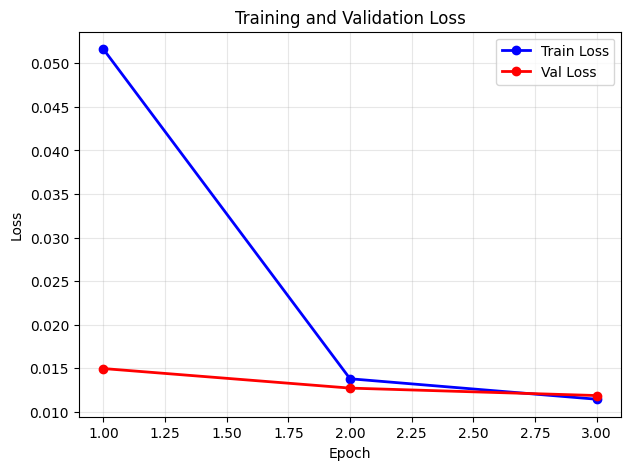

In [ ]:

print("\n" + "="*70)
print("Plotting learning curves...")
print("="*70)

# Plot 1: Training and Validation Loss
plt.figure(figsize=(7,5))
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Train Loss', linewidth=2)
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-o', label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../results/plots/section4/loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

We observe that the training loss decreases sharply during the first epoch (0.5477 → 0.0516) and continues to decline gradually. We can assume that the BERT model is effectively adapting to the syntas of SSH command sequences.
At the end of the third epoch we achieve convergence, where train_loss = 0.0114 and val_loss = 0.0119.

Moreover the inverted behavior we had at the beginning, where val_loss < train_loss, indicates strong regularization. Dropout is preventing the model from memorizing the dominant classes.

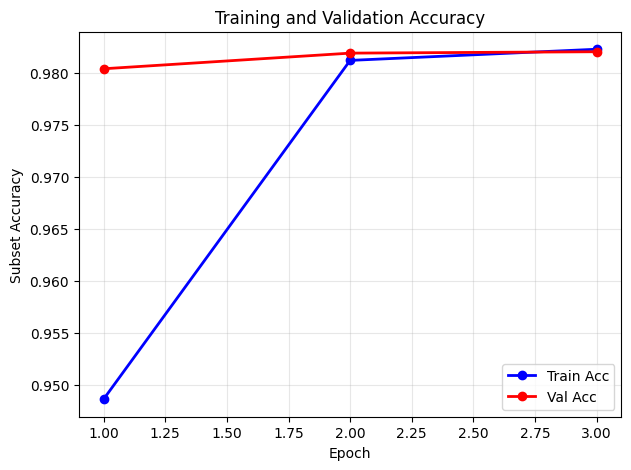

In [ ]:
# Plot 2: Training and Validation Accuracy
plt.figure(figsize=(7,5))
plt.plot(range(1, len(train_accs) + 1), train_accs, 'b-o', label='Train Acc', linewidth=2)
plt.plot(range(1, len(val_accs) + 1), val_accs, 'r-o', label='Val Acc', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Subset Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../results/plots/section4/accuracy_curve.png', dpi=300, bbox_inches='tight')
plt.show()

Subset accuracy improves from 94.86% (Epoch 1) to 98.22% (Epoch 3), showing consistent learning across all 3 epochs.

The strong upward trend of the train_acc variable shows us that the model has successfully learned to predict the entire set of intents for the majority of SSH sessions.

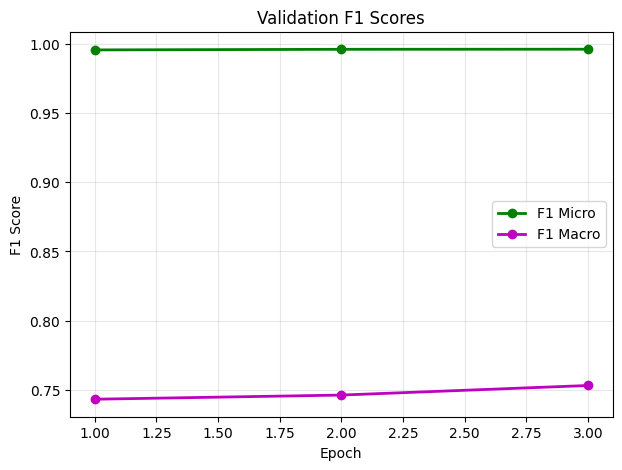

In [ ]:
# Plot 3: Validation F1 Scores
plt.figure(figsize=(7,5))
plt.plot(range(1, len(val_f1_micros) + 1), val_f1_micros, 'g-o', label='F1 Micro', linewidth=2)
plt.plot(range(1, len(val_f1_macros) + 1), val_f1_macros, 'm-o', label='F1 Macro', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('Validation F1 Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../results/plots/section4/f1_scores.png', dpi=300, bbox_inches='tight')
plt.show()


Macro-F1 improves from 0.7433 → 0.7532, a little but meaningful ~1% gain. This improvement reflects a better handling of rare classes despite their extreme imbalance.

As for the Micro-F1 Score (~0.99) it keeps high and stable. This reflects the model high reliability in detecting the most frequent attack tactics (Discovery and Execution) which comprise the majority of our data.

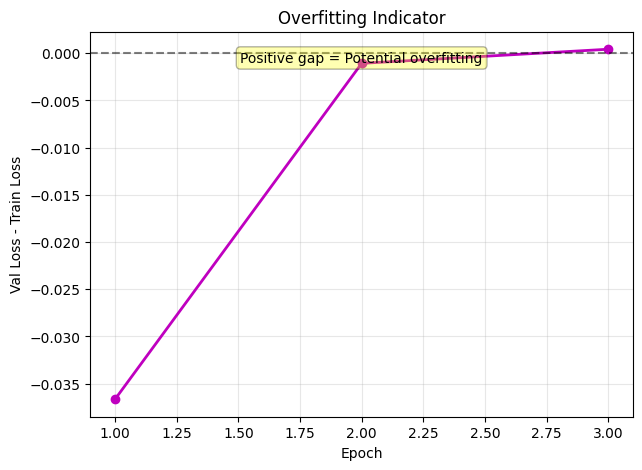

In [ ]:
# Plot 4: Overfitting Indicator 
plt.figure(figsize=(7,5))
gap = np.array(val_losses) - np.array(train_losses)
plt.plot(range(1, len(gap) + 1), gap, 'm-o', linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Epoch')
plt.ylabel('Val Loss - Train Loss')
plt.title('Overfitting Indicator')
plt.grid(True, alpha=0.3)

if gap[-1] > 0:
    plt.text(0.5, 0.95, 'Positive gap = Potential overfitting',
             transform=plt.gca().transAxes, ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.savefig('../results/plots/section4/overfitting_indicator.png', dpi=300, bbox_inches='tight')
plt.show()

At the beginning of the first epoch we observe that the indicator starts in the negative region, meaning that our Dropout is effectively challenging our model during training. As the epochs progress, the indicator trends upward toward the zero-axis meaning that the model is stabilizing.

At the end of the third epoch the indicator is extremely close to 0 (approximately +0.0005). If the line started climbing above 0, we would have had overfitting. However, since it reamins near 0, we understand that the model has learned the maximum number of information while maintaining generalization capabilities.

This final consideration confirms that the choice of 3 epochs fits perfectly our model since a fourth model would have triggered early stopping with no improvement in performance.

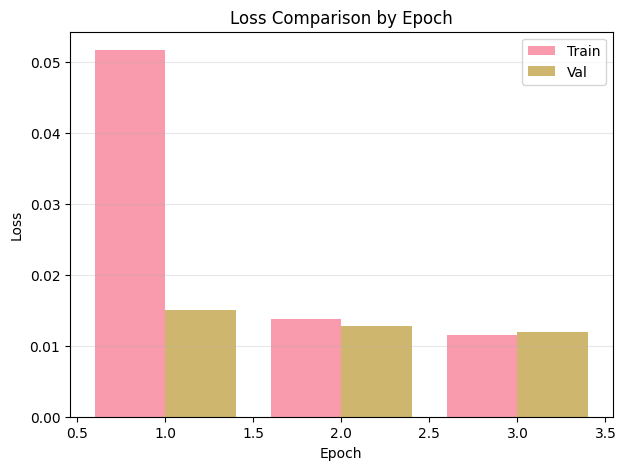

In [ ]:
# Plot 5: Loss values comparison by epoch
plt.figure(figsize=(7,5))
epochs_range = range(1, len(train_losses) + 1)
plt.bar([x - 0.2 for x in epochs_range], train_losses, width=0.4, label='Train', alpha=0.7)
plt.bar([x + 0.2 for x in epochs_range], val_losses, width=0.4, label='Val', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Comparison by epoch')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.savefig('../results/plots/section4/loss_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


Here we can visualize better how convergance is met between training and validation loss.

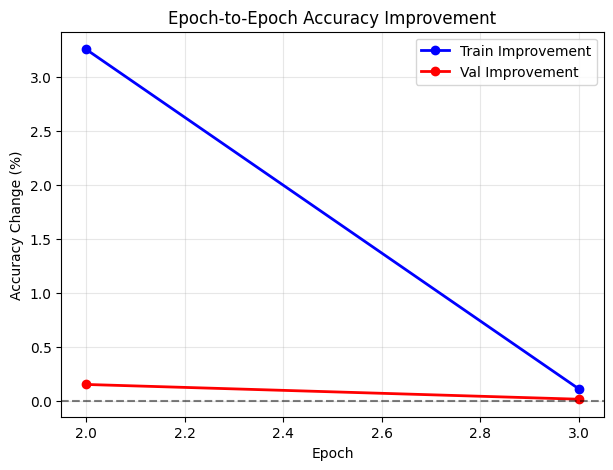


All learning curves saved


In [ ]:
# Plot 6: Accuracy improvement
plt.figure(figsize=(7,5))
train_improvement = [(train_accs[i] - train_accs[i-1]) * 100 for i in range(1, len(train_accs))]
val_improvement = [(val_accs[i] - val_accs[i-1]) * 100 for i in range(1, len(val_accs))]

plt.plot(range(2, len(train_accs) + 1), train_improvement, 'b-o', label='Train Improvement', linewidth=2)
plt.plot(range(2, len(val_accs) + 1), val_improvement, 'r-o', label='Val Improvement', linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Epoch')
plt.ylabel('Accuracy Change (%)')
plt.title('Epoch-to-Epoch Accuracy Improvement')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../results/plots/section4/accuracy_improvement.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAll learning curves saved")


The curves almost meet by epoch 3, both stabilizing, confirming that the model has reached high predictive power and validating our choice to stop training at this point.

In [54]:
# Analysis based on training and validation

print("--- Analysis of the model based on training and validation ---")
# Find best epoch
best_epoch_idx = np.argmin(val_losses)
print(f"\nBest epoch: {best_epoch_idx + 1}")
print(f"Best validation loss: {val_losses[best_epoch_idx]:.4f}")
print(f"Best validation F1 (micro): {val_f1_micros[best_epoch_idx]:.4f}")

# Check for overfitting
if len(val_losses) > 1:
    if val_losses[-1] > val_losses[-2]:
        print("\nWarning: Validation loss increased in last epoch")
        print("Model may be starting to overfit")
        print(f"Recommendation: Use model from epoch {best_epoch_idx + 1}")
    else:
        print("\nValidation loss is decreasing or stable")
        print("Model is learning effectively")


--- Analysis of the model based on training and validation ---

Best epoch: 3
Best validation loss: 0.0119
Best validation F1 (micro): 0.9960

Validation loss is decreasing or stable
Model is learning effectively


## Step 6: Final Evaluation on Test Set

We first evaluate the fine-tuned BERT model on the test set and then we analyze the results. We aim to understand how well the model generalizes its understanding of Unix command sequences to sessions it has never encountered before.

### Step 6.1: Test Set Evaluation

In [ ]:
print("\n" + "="*70)
print("FINAL TEST SET EVALUATION")
print("="*70)

# Load best model
print("\n\nLoading best model...")
checkpoint = torch.load('../results/best_model.pt', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Best model loaded from epoch {checkpoint['epoch'] + 1}")
print(f"  Training loss: {checkpoint['train_loss']:.4f}")
print(f"  Validation loss: {checkpoint['val_loss']:.4f}")
print(f"  Validation F1 (micro): {checkpoint['val_f1_micro']:.4f}")

# Evaluate on test set
print("\n--- Testing Phase ---")
test_loss, test_acc, test_hamming, test_f1_micro, test_f1_macro = eval_one_epoch(
    model, test_loader, criterion, device
)

# Print test results
print("\n\n--- Test Set Results ---")
print(f"Test Loss:        {test_loss:.4f}")
print(f"Test Accuracy:    {test_acc:.4f}")
print(f"Test Hamming Loss: {test_hamming:.4f}")
print(f"Test F1 Micro:    {test_f1_micro:.4f}")
print(f"Test F1 Macro:    {test_f1_macro:.4f}")


FINAL TEST SET EVALUATION


Loading best model...
Best model loaded from epoch 3
  Training loss: 0.0114
  Validation loss: 0.0119
  Validation F1 (micro): 0.9960

--- Testing Phase ---
Starting evaluation on 1457 batches...


Evaluating:   0%|          | 0/1457 [00:00<?, ?it/s]



--- Test Set Results ---
Test Loss:        0.0122
Test Accuracy:    0.9820
Test Hamming Loss: 0.0028
Test F1 Micro:    0.9960
Test F1 Macro:    0.7553


The model maintains almost identical performance on the test set, meaning that it generalizes reliably to unseen data.

### Step 6.2: Per-Class Performance Analysis

We analyze the model's effectivness among all the different intents. We expect different performance based on class abundance and distinctiveness.

In [46]:

print("\n" + "="*70)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("="*70)

# Get all predictions on test set
print("\nGenerating predictions for detailed analysis...")
all_preds = []
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Getting predictions"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids=input_ids, attention_mask=attention_mask)

        probs = torch.sigmoid(logits)
        predictions = (torch.sigmoid(logits) > 0.5).float()

        all_preds.append(predictions.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)
all_probs = np.vstack(all_probs) 


print(f"\nPredictions generated for {len(all_preds):,} test samples")

# Print classification report for each intent
print("\n" + "="*70)
print("CLASSIFICATION REPORT BY INTENT")
print("="*70)

# Store per-class metrics for summary
per_class_metrics = []

for i, label in enumerate(label_columns):
    print(f"\n{'─'*70}")
    print(f"{label.upper()}")
    print(f"{'─'*70}")

    # Calculate metrics
    y_true = all_labels[:, i]
    y_pred = all_preds[:, i]

    # Class distribution
    positive_samples = int(y_true.sum())
    negative_samples = len(y_true) - positive_samples

    print(f"Distribution: {positive_samples:,} positive ({positive_samples/len(y_true)*100:.2f}%), "
          f"{negative_samples:,} negative ({negative_samples/len(y_true)*100:.2f}%)")

    # Classification report
    report = classification_report(
        y_true,
        y_pred,
        target_names=['Negative', 'Positive'],
        digits=4,
        zero_division=0,
        output_dict=True
    )

    # Print formatted report
    print(f"\nMetrics:")
    print(f"  Precision (Positive): {report['Positive']['precision']:.4f}")
    print(f"  Recall (Positive):    {report['Positive']['recall']:.4f}")
    print(f"  F1-Score (Positive):  {report['Positive']['f1-score']:.4f}")
    print(f"  Support:              {int(report['Positive']['support']):,} samples")

    # Store for summary
    per_class_metrics.append({
        'Intent': label,
        'Samples': positive_samples,
        'Percentage': positive_samples/len(y_true)*100,
        'Precision': report['Positive']['precision'],
        'Recall': report['Positive']['recall'],
        'F1-Score': report['Positive']['f1-score']
    })

# Create summary table
print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)

summary_df = pd.DataFrame(per_class_metrics)
print("\n" + summary_df.to_string(index=False))

# Identify best and worst performing classes
best_f1_idx = summary_df['F1-Score'].idxmax()
worst_f1_idx = summary_df['F1-Score'].idxmin()

print(f"\nBest performing intent: {summary_df.loc[best_f1_idx, 'Intent']} "
      f"(F1: {summary_df.loc[best_f1_idx, 'F1-Score']:.4f})")
print(f"Worst performing intent: {summary_df.loc[worst_f1_idx, 'Intent']} "
      f"(F1: {summary_df.loc[worst_f1_idx, 'F1-Score']:.4f})")

# Analysis of imbalanced classes
print("\n--- Class Imbalance Analysis ---")
rare_classes = summary_df[summary_df['Percentage'] < 1.0]
common_classes = summary_df[summary_df['Percentage'] > 50.0]

if len(rare_classes) > 0:
    print(f"\nRare classes (<1% of data):")
    for _, row in rare_classes.iterrows():
        print(f"  - {row['Intent']}: {row['Samples']:,} samples ({row['Percentage']:.2f}%) - "
              f"F1: {row['F1-Score']:.4f}")

if len(common_classes) > 0:
    print(f"\nCommon classes (>50% of data):")
    for _, row in common_classes.iterrows():
        print(f"  - {row['Intent']}: {row['Samples']:,} samples ({row['Percentage']:.2f}%) - "
              f"F1: {row['F1-Score']:.4f}")


PER-CLASS PERFORMANCE ANALYSIS

Generating predictions for detailed analysis...


Getting predictions:   0%|          | 0/1457 [00:00<?, ?it/s]


Predictions generated for 46,607 test samples

CLASSIFICATION REPORT BY INTENT

──────────────────────────────────────────────────────────────────────
PERSISTENCE
──────────────────────────────────────────────────────────────────────
Distribution: 42,281 positive (90.72%), 4,326 negative (9.28%)

Metrics:
  Precision (Positive): 0.9994
  Recall (Positive):    0.9996
  F1-Score (Positive):  0.9995
  Support:              42,281 samples

──────────────────────────────────────────────────────────────────────
DISCOVERY
──────────────────────────────────────────────────────────────────────
Distribution: 46,433 positive (99.63%), 174 negative (0.37%)

Metrics:
  Precision (Positive): 0.9999
  Recall (Positive):    0.9998
  F1-Score (Positive):  0.9999
  Support:              46,433 samples

──────────────────────────────────────────────────────────────────────
DEFENSE EVASION
──────────────────────────────────────────────────────────────────────
Distribution: 3,760 positive (8.07%), 42,847 

This investigation led us to the following distinctions based on classes:

- Majority classes: Discovery (F1: 0.9999, 99.63% of data) and Persistence (F1: 0.9995, 90.72% of data) achieve near-perfect classification. Both intents conver the majority of the dataset and have abundant training data and distinctive command patterns.

- Well-represented classes: Execution (F1: 0.9910, 39.72% of data) and Defense Evasion (F1: 0.9835, 8.07%) maintain excellent performance despite lower prevalence in the set. This means that those intents still have sufficient training data to learn recognizable patterns. 

- Rare classes: Other (F1: 0.9925, 67 samples) surprisingly achieves strong performance despite the few samples. This suggests that the sessions in this category possess high linguistic uniqueness. Even with few samples, the command sequences are so distinct from other tactics that the model identifies them with high precision. Harmless (F1: 0.3211, 458 samples) which is the most problematic category. Even considering more samples than Other, the shell commands also appear in most malicious sessions and cannot be properly distinguished. The model learned to avoid predicting Harmless unless extremely confident.

- Impossible class: Impact (F1: 0.0000, 2 test samples, 27 training samples) represents a data problem, not a model problem. With only 27 samples, the model cannot learn a distinct pattern. It defaults to the majority classes, achieving 100% true negatives but 0% recall on the 2 Impact samples.
This is an expected behavior and aligns with the experience from Section 2's traditional ML approach, which also struggled with Impact (F1: 0.67, only because it coincidentally caught 1 of 2 test samples). This confirms that the bottleneck for this specific tactic is the lack of representative data rather than the choice of algorithm.

Considering this whole consideration about classes, we can also understand the gap between F1 scores and accuracy:

- Micro F1 and Accuracy are extremely high because the model is performing nearly perfectly on the "majority" classes.
- The Macro F1 (75.53%) is significantly lower because it treats every intent equally. This lower score is dragged down by the model's failure to identify rare intents like "Impact".

### Step 6.3: Visualization of final results


Creating performance visualization...


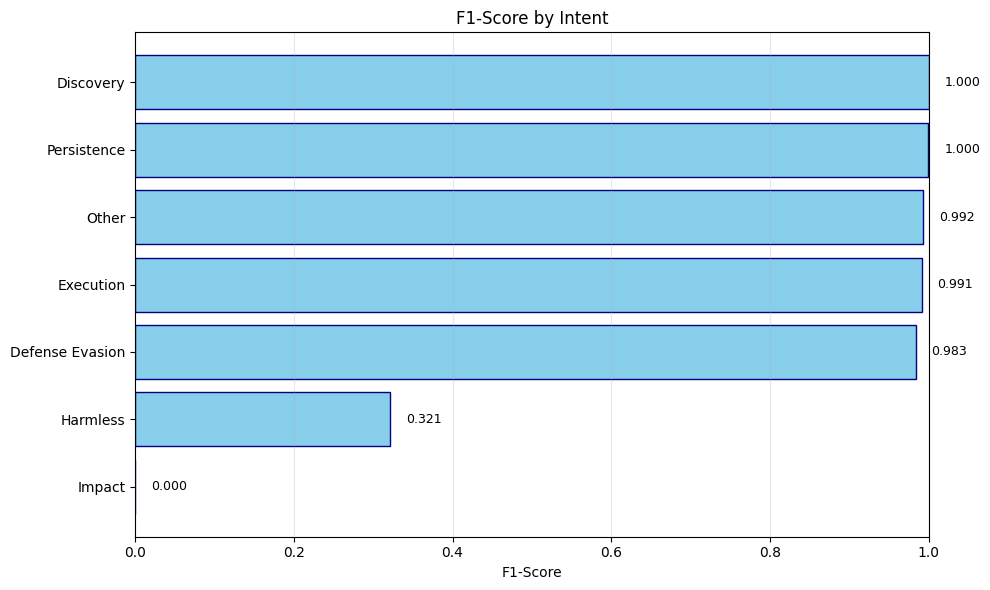

In [ ]:

print("\n" + "="*70)
print("Creating performance visualization...")
print("="*70)

# Plot 1: F1-Scores by Intent
plt.figure(figsize=(10, max(6, 0.25 * len(summary_df))))
summary_df_sorted = summary_df.sort_values('F1-Score', ascending=True).reset_index(drop=True)
y_pos = np.arange(len(summary_df_sorted))
plt.barh(y_pos, summary_df_sorted['F1-Score'], color='skyblue', edgecolor='navy')
plt.yticks(y_pos, summary_df_sorted['Intent'])
plt.xlabel('F1-Score')
plt.title('F1-Score by Intent')
plt.xlim(0, 1)
plt.grid(True, axis='x', alpha=0.3)
for i, v in enumerate(summary_df_sorted['F1-Score']):
    plt.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/plots/section4/f1_by_intent.png', dpi=300, bbox_inches='tight')
plt.show()


This visually confirms the class imbalance effect.

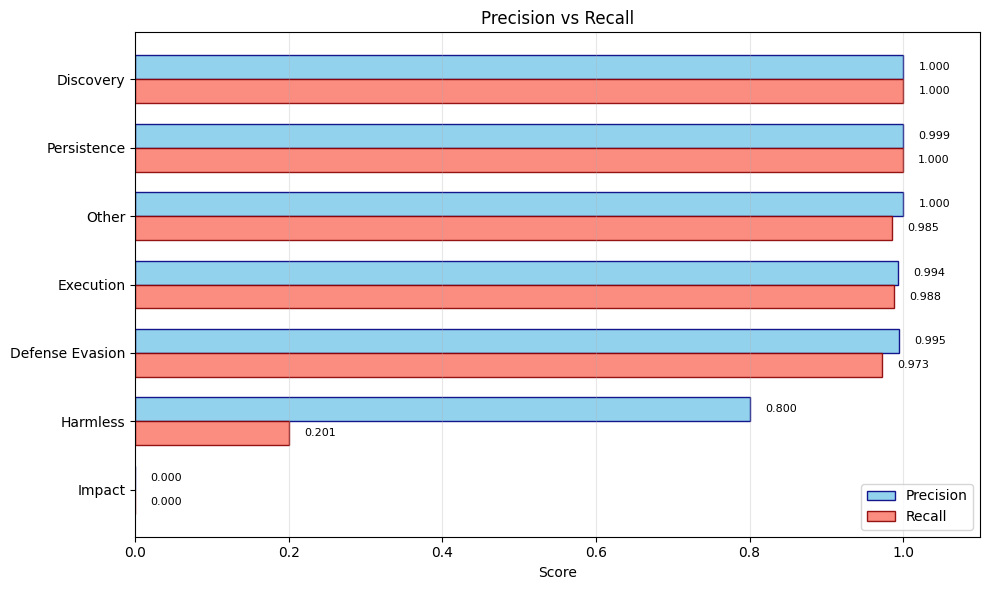

In [ ]:
# Plot 2: Precision vs Recall
plt.figure(figsize=(10, max(6, 0.4 * len(summary_df))))
height = 0.35  
plt.barh(y_pos + height/2, summary_df_sorted['Precision'], height, label='Precision', 
         color='skyblue', edgecolor='navy', alpha=0.9)
plt.barh(y_pos - height/2, summary_df_sorted['Recall'], height, label='Recall', 
         color='salmon', edgecolor='darkred', alpha=0.9)
plt.yticks(y_pos, summary_df_sorted['Intent'])
plt.xlabel('Score')
plt.title('Precision vs Recall')
plt.xlim(0, 1.1) 
plt.grid(True, axis='x', alpha=0.3)
plt.legend(loc='lower right')

for i, (p, r) in enumerate(zip(summary_df_sorted['Precision'], summary_df_sorted['Recall'])):
    plt.text(p + 0.02, i + height/2, f'{p:.3f}', va='center', fontsize=8)
    plt.text(r + 0.02, i - height/2, f'{r:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../results/plots/section4/precision_recall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


It reveals two strategies:
- Majority classes: high and balanced precision/recall (both ≥0.97)
- Rare classes: Conservative precision, low recall

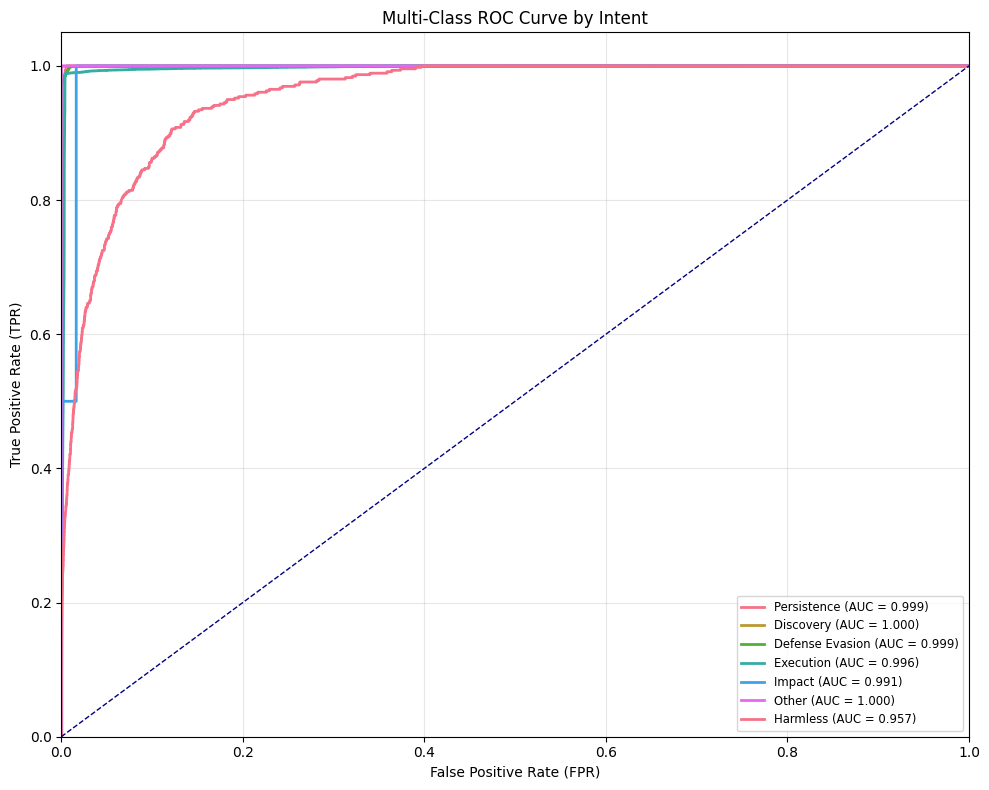

In [ ]:
# Plot 3: ROC curve by Intent
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10, 8))
intents = summary_df['Intent'].tolist()

for i, label in enumerate(intents):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Multi-Class ROC Curve by Intent')
plt.legend(loc="lower right", fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/plots/section4/roc_curve_final.png', dpi=300, bbox_inches='tight')
plt.show()

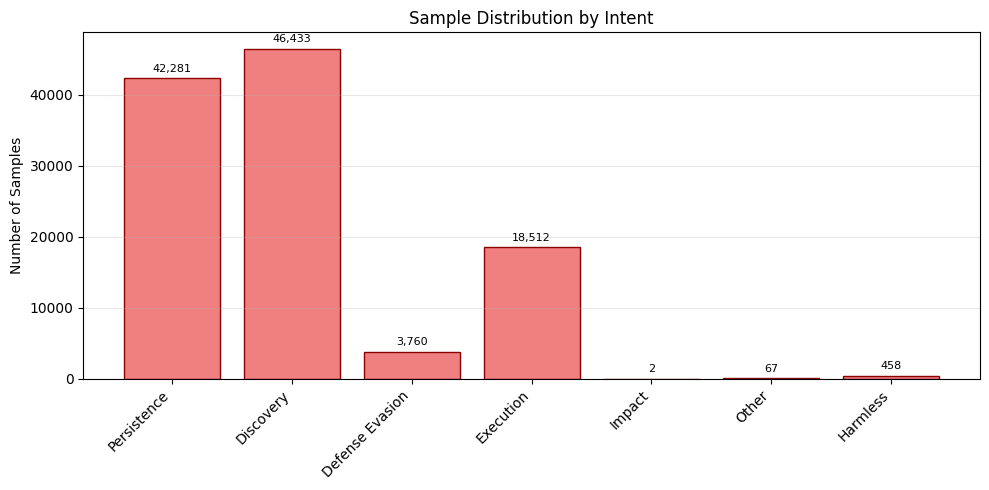

In [ ]:
# Plot 4: Sample Distribution
plt.figure(figsize=(10, max(5, 0.25 * len(summary_df))))
plt.bar(summary_df['Intent'], summary_df['Samples'], color='lightcoral', edgecolor='darkred')
plt.ylabel('Number of Samples')
plt.title('Sample Distribution by Intent')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', alpha=0.3)
max_samples = summary_df['Samples'].max() if len(summary_df) > 0 else 1
for i, v in enumerate(summary_df['Samples']):
    plt.text(i, v + max_samples * 0.02, f'{v:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../results/plots/section4/sample_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


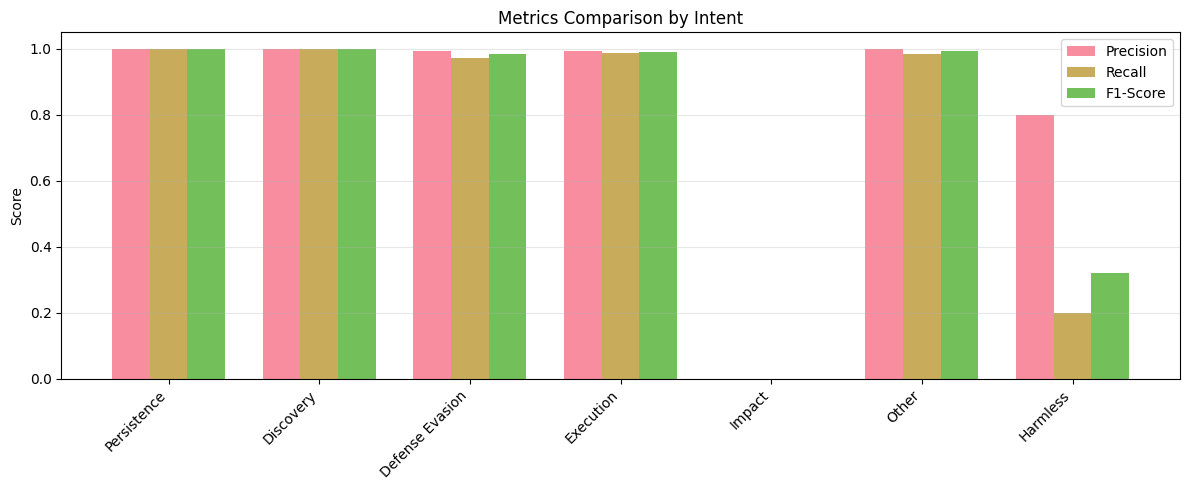

In [ ]:
# Plot 5: Metrics Comparison
plt.figure(figsize=(12, max(5, 0.25 * len(summary_df))))
x = np.arange(len(summary_df))
width = 0.25
plt.bar(x - width, summary_df['Precision'], width, label='Precision', alpha=0.8)
plt.bar(x, summary_df['Recall'], width, label='Recall', alpha=0.8)
plt.bar(x + width, summary_df['F1-Score'], width, label='F1-Score', alpha=0.8)
plt.ylabel('Score')
plt.title('Metrics Comparison by Intent')
plt.xticks(x, summary_df['Intent'], rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/plots/section4/metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


We can observe the total absence of Impact across the other intents.

## Final Summary

In [53]:

print("\nFINAL RESULTS SUMMARY:")
print(f"  Test Loss:         {test_loss:.4f}")
print(f"  Test Accuracy:     {test_acc:.4f}")
print(f"  Test F1 Micro:     {test_f1_micro:.4f}")
print(f"  Test F1 Macro:     {test_f1_macro:.4f}")
print(f"  Test Hamming Loss: {test_hamming:.4f}")

print("\nTRAINING SUMMARY:")
print(f"  Total epochs trained: {len(train_losses)}")
print(f"  Best epoch: {best_epoch_idx + 1}")
print(f"  Final train loss: {train_losses[-1]:.4f}")
print(f"  Final val loss: {val_losses[-1]:.4f}")

print("\nKEY FINDINGS:")
print(f"  Best performing intent: {summary_df.loc[best_f1_idx, 'Intent']} "
      f"(F1: {summary_df.loc[best_f1_idx, 'F1-Score']:.4f})")
print(f"  Most challenging intent: {summary_df.loc[worst_f1_idx, 'Intent']} "
      f"(F1: {summary_df.loc[worst_f1_idx, 'F1-Score']:.4f})")
print(f"  Average F1 across intents: {summary_df['F1-Score'].mean():.4f}")



FINAL RESULTS SUMMARY:
  Test Loss:         0.0122
  Test Accuracy:     0.9820
  Test F1 Micro:     0.9960
  Test F1 Macro:     0.7553
  Test Hamming Loss: 0.0028

TRAINING SUMMARY:
  Total epochs trained: 3
  Best epoch: 3
  Final train loss: 0.0114
  Final val loss: 0.0119

KEY FINDINGS:
  Best performing intent: Discovery (F1: 0.9999)
  Most challenging intent: Impact (F1: 0.0000)
  Average F1 across intents: 0.7553


### BERT vs Traditional ML 

Comparing our BERT model to the results obtained in section 2 using Tuned LR, we can notice that, even if some values are slightly different (Accuracy: 98.20% vs 98.43%, Micro-F1: 99.60% vs 99.64%), the big difference is done in the Macro-F1 results (75.53% vs 84.63%).
Overall, we can declare that traditional ML achieves better performance than our BERT model, especially in terms of Macro-F1.

Comparing both models on a per-intent breakdown lead us to the following considerations:

- For well-represented intents, both approaches achieve near-perfect scores (F1 >= 0.98). This means that those intents have a very distinctive command pattern that even TF-IDF captures them effectively. For this reason, the attack commands don't require context understanding and the usage of BERT model doesn't provide any benefit.

- The biggest difference between the two approaches is in the results related to the Impact class. While BERT achieves a F1-score = 0, classifying all impact samples as negatives, the other approach achieves a F1-score = 0.67, by correctly classifying 1 out of 2 Impact samples. This reflects the dependance of BERT to class imbalance, leading it to defaults to majority classes and ignoring rare classes. 
